In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import yaml

shot_number = 170000
yaml_path = "/scratch/gpfs/nc1514/FusionAIHub/src/fusionaihub/datasets/prepare/config/default.yaml"
with open(yaml_path, 'r') as f:
    cfg = yaml.safe_load(f)

from fusionaihub.datasets.prepare.data_extraction import (
    extract_signal, 
    extract_running_time, 
    align_signal,
)
from fusionaihub.datasets.prepare.sample_processing import (
    split_samples,
    remove_empty_samples,
    save_sample,
)
from fusionaihub.datasets.prepare.signal_processing import (
    identity_transform,
    stft_transform,
    resample_transform,
)

In [3]:
start_time, end_time = extract_running_time(
    shot_number=shot_number,
    directory=Path(cfg["raw_data_dir"]),
    ip_threshold=cfg["ip_threshold"],
    start_time=cfg["start_time"],
    end_time=cfg["end_time"],
    )

In [4]:
dfs = []
missing_signals = []
for signal in cfg["signal"]:
    try:
        df = extract_signal(
            shot_number=shot_number,
            directory=Path(cfg["raw_data_dir"]),
            signal=signal['name'], 
            start_time=start_time,
            end_time=end_time,
        )
        df.columns = [
            f"{signal['abbr']}_{col}" if col != "time" else col
            for col in range(len(df.columns))
        ]

        # Add a column to the dataframe for this signal indicating if a transform is present.
        # We'll use the signal's abbreviation to name the column, e.g., 'IP_transform'
        df = align_signal(
            df=df,
            start_time=start_time,
            end_time=end_time,
            fs=cfg["fs_khz"],
        )
        dfs.append(df)
    except Exception as e:
        missing_signals.append((signal['name'], signal['abbr']))

In [55]:
df = pd.concat(dfs, axis=1, join='inner')
for signal_name, signal_abbr in missing_signals:
    df[signal_abbr] = 0.0
    df[f"{signal_abbr}_state"] = False

In [56]:
samples = split_samples(
    df=df,
    shot_number=shot_number,
    window_ms=cfg["window_ms"],
    hop_ms=cfg["hop_ms"],
    fs_khz=cfg["fs_khz"],
)

In [57]:
samples = remove_empty_samples(samples)

In [ ]:
for sample in samples:
    transformed_samples = {}
    for key, value in sample.items():
        for signal in cfg["signal"]:
            abbr = signal['abbr']
            cols = [col for col in value.columns if abbr in col]
            transformed_samples[abbr] = identity_transform(
                x=value[cols].to_numpy().T)
            print(abbr, transformed_samples[abbr].shape)
        save_sample(transformed_samples, Path('.'), key)

mhr (8, 1, 2832874)
ece (48, 1, 2832874)
co2 (4, 1, 2832874)
gas (5, 1, 2832874)
ech (11, 1, 2832874)
pin (8, 1, 2832874)
tin (8, 1, 2832874)


In [58]:
first_arr = list(samples[0].values())[0].iloc[:, 0].values
transform_shape = stft_transform(x=first_arr).shape
print(first_arr.shape, transform_shape)

(2832874,) (513, 11066)


In [83]:
for sample in samples:
    transformed_samples = {}
    for key, value in sample.items():
        for signal in cfg["signal"]:
            abbr = signal['abbr']
            cols = [col for col in value.columns if abbr in col]
            if signal["make_stft"]:
                transformed_samples[abbr] = stft_transform(
                    x=value[cols].to_numpy().T,
                    n_fft=cfg["stft"]["n_fft"],
                    hop_length=cfg["stft"]["hop_length"],
                )
            else:
                transformed_samples[abbr] = resample_transform(
                    x=value[cols].to_numpy().T,
                    ref_shape=transform_shape,
                )
            print(abbr, transformed_samples[abbr].shape)
        save_sample(transformed_samples, Path('.'), key)
        break
    break

mhr (8, 513, 11066)
ece (48, 513, 11066)
co2 (4, 513, 11066)
gas (5, 1, 11066)
ech (11, 1, 11066)
pin (8, 1, 11066)
tin (8, 1, 11066)


In [85]:
import joblib
test_load = joblib.load('/scratch/gpfs/EKOLEMEN/nc1514/foundation_v2/train/170000_0.pkl')
print(test_load['mhr'].dtype)

float32


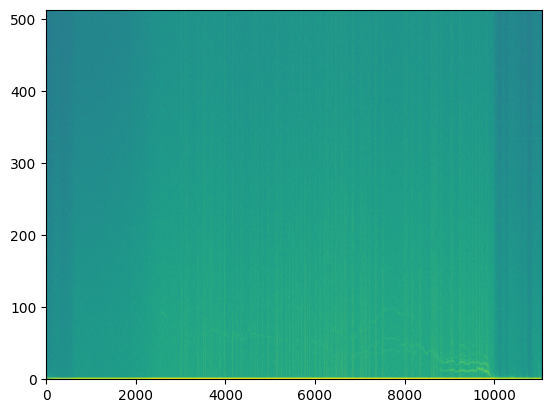

In [86]:
plt.imshow(test_load['ece'][4], aspect='auto', origin='lower')
plt.show()